# 02 - Exploratory Data Analysis (EDA)
## Loan Risk Assessment System

**Objective:** Explore relationships between applicant attributes and loan approval outcomes, and visualize feature distributions.

**Workflow:**
1. Load cleaned dataset
2. Feature engineering (for numeric distribution plots)
3. Approval rate breakdowns by category
4. Numeric distributions
5. Correlation heatmap

In [1]:
import sys
sys.path.append('..')

import pandas as pd
from IPython.display import Image, display
from src import config
from src.data_loader import load_dataset
from src.feature_engineering import engineer_features
from src.visualization import (
    plot_approval_rate_by_category, plot_distribution,
    plot_correlation_heatmap
)

raw_df = load_dataset(config.RAW_DATA_PATH)
cleaned_df = pd.read_csv(config.CLEANED_DATA_PATH)
engineered_df = engineer_features(cleaned_df)
engineered_df.head()

[2026-07-31 19:26:19] INFO - src.data_loader - Dataset loaded successfully from /home/claude/AIML-BonusProject-Loan-Risk-Assessment/Dataset/loan_prediction.csv with shape (614, 13)


[2026-07-31 19:26:19] INFO - src.feature_engineering - Starting feature engineering pipeline...


[2026-07-31 19:26:19] INFO - src.feature_engineering - Created feature: 'total_income'


[2026-07-31 19:26:19] INFO - src.feature_engineering - Created feature: 'loan_income_ratio'


[2026-07-31 19:26:19] INFO - src.feature_engineering - Converted 'Dependents' to numeric (3+ mapped to 3)


[2026-07-31 19:26:19] INFO - src.feature_engineering - Encoded target column 'Loan_Status': Y -> 1, N -> 0


[2026-07-31 19:26:19] INFO - src.feature_engineering - One-hot encoded columns: ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']. New shape: (614, 15)


[2026-07-31 19:26:19] INFO - src.feature_engineering - Feature engineering complete. Final shape: (614, 15)


,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,total_income,loan_income_ratio,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,3,11135,1773.0,700.0,360.0,1.0,1,12908.0,0.054230,1,1,0,0,0,1
1,0,8800,0.0,700.0,360.0,1.0,1,8800.0,0.079545,1,0,1,0,0,0
2,0,19532,0.0,700.0,360.0,1.0,0,19532.0,0.035839,0,0,0,0,0,0
3,1,2406,5935.0,700.0,360.0,1.0,1,8341.0,0.083923,1,1,0,0,1,0
4,0,11522,3071.0,700.0,360.0,1.0,1,14593.0,0.047968,1,1,0,1,0,0


## Approval Rate by Credit History

Credit history is typically the single strongest predictor of loan approval — applicants with a confirmed good credit history should show a much higher approval rate.

[2026-07-31 19:26:19] INFO - src.visualization - Saved figure: /home/claude/AIML-BonusProject-Loan-Risk-Assessment/Images/approval_credit_history.png


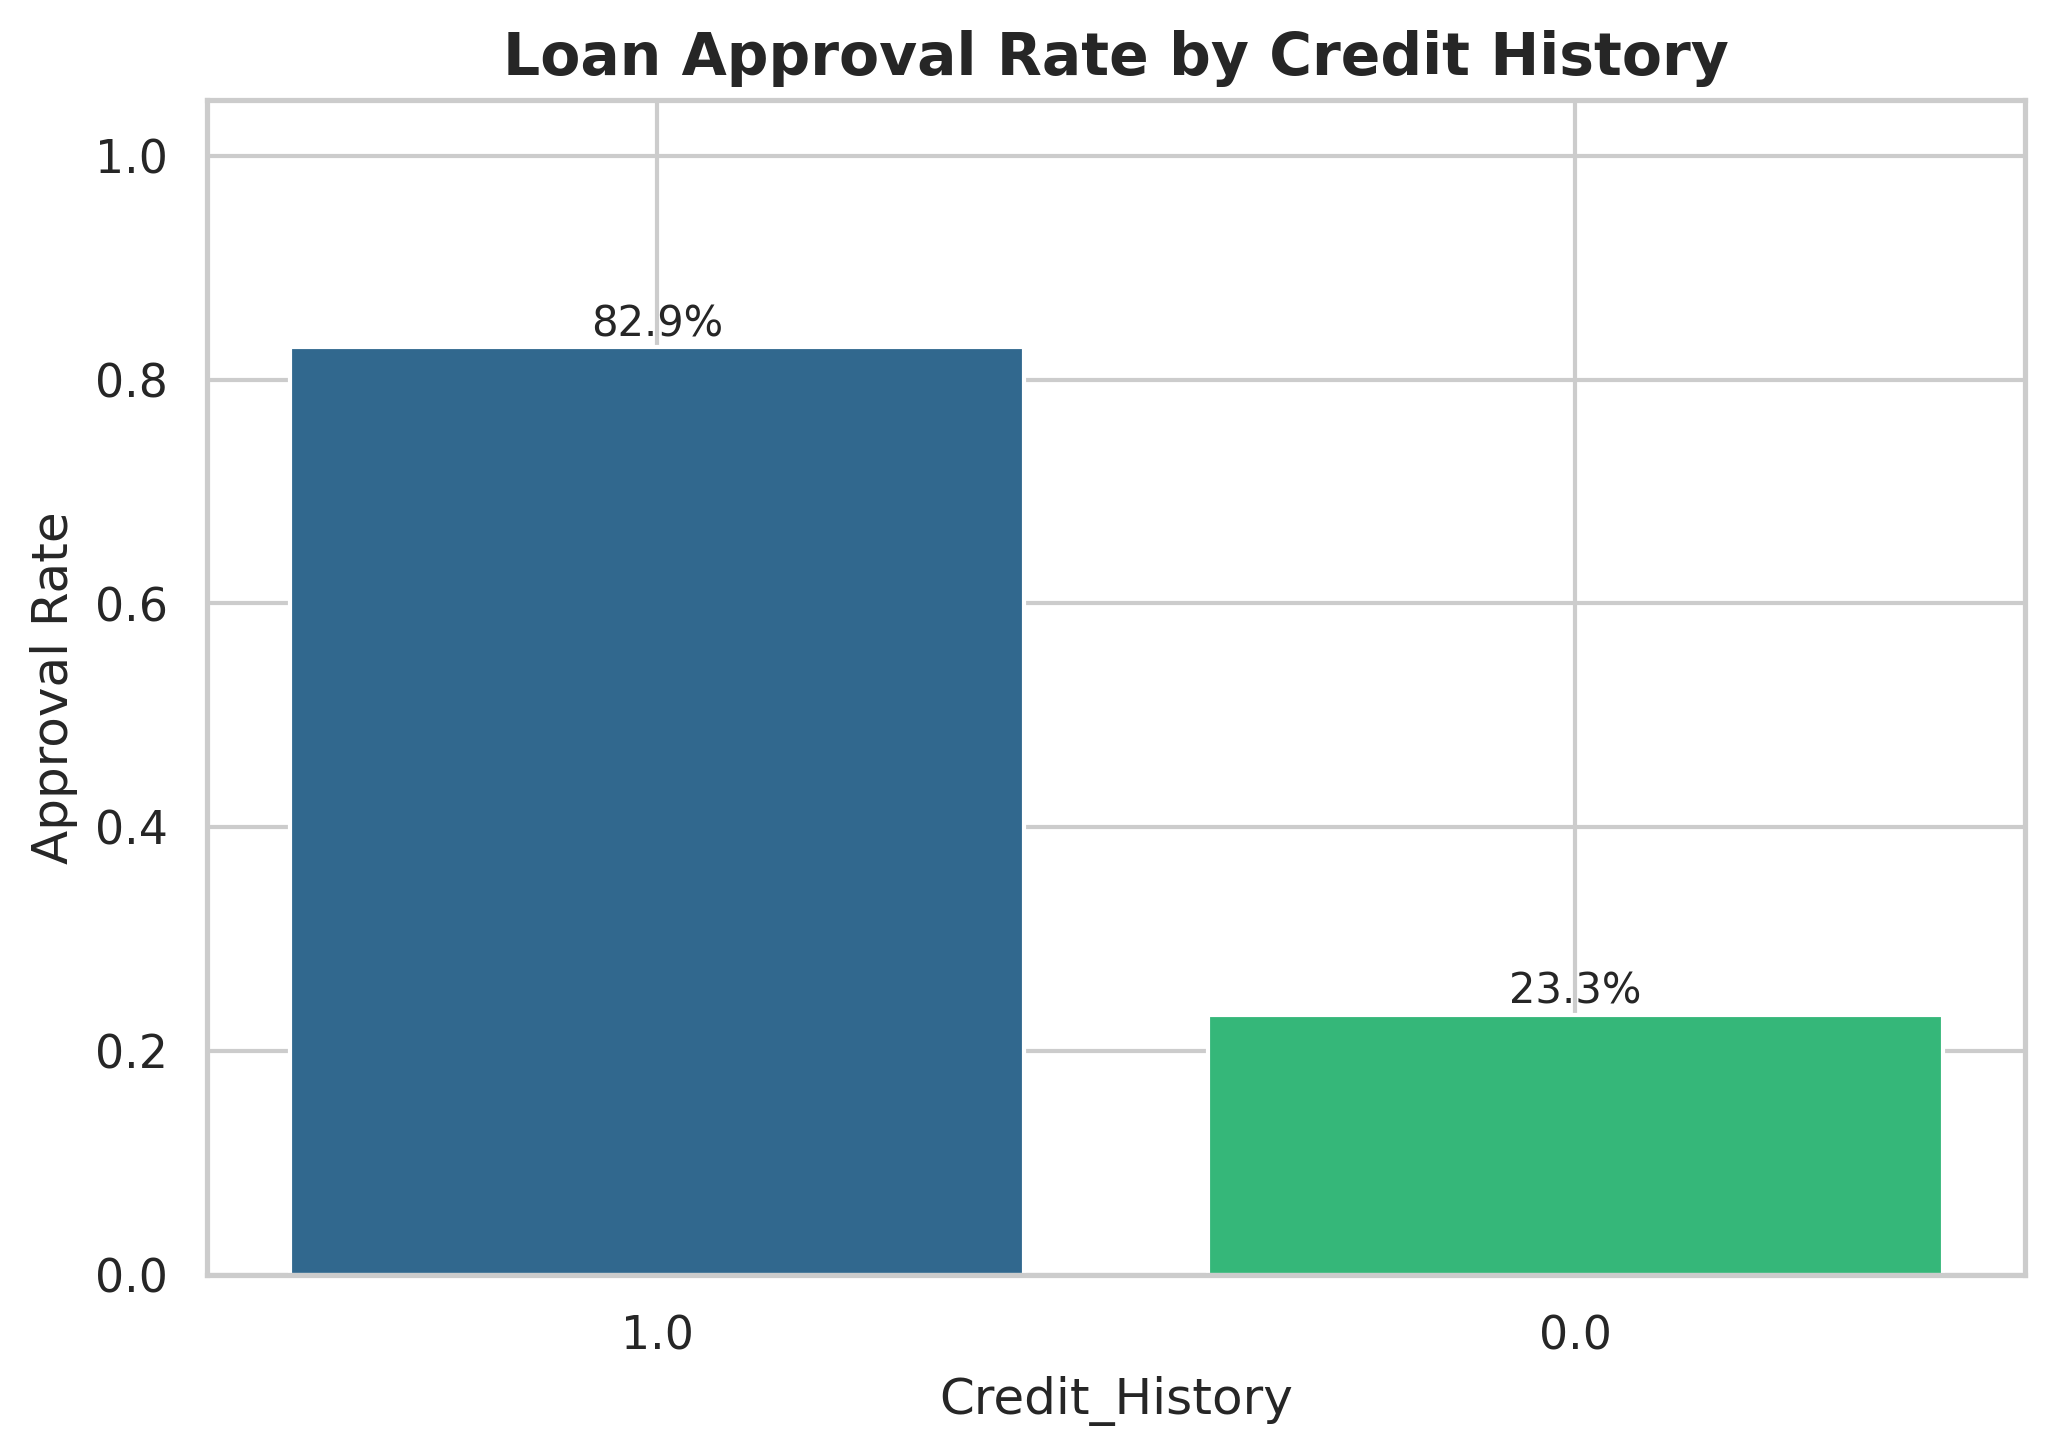

In [2]:
plot_approval_rate_by_category(
    raw_df, 'Credit_History', 'Loan_Status',
    'Loan Approval Rate by Credit History',
    config.IMAGES_DIR / 'approval_credit_history.png'
)
display(Image(filename=str(config.IMAGES_DIR / 'approval_credit_history.png')))

## Approval Rate by Property Area

[2026-07-31 19:26:19] INFO - src.visualization - Saved figure: /home/claude/AIML-BonusProject-Loan-Risk-Assessment/Images/approval_property_area.png


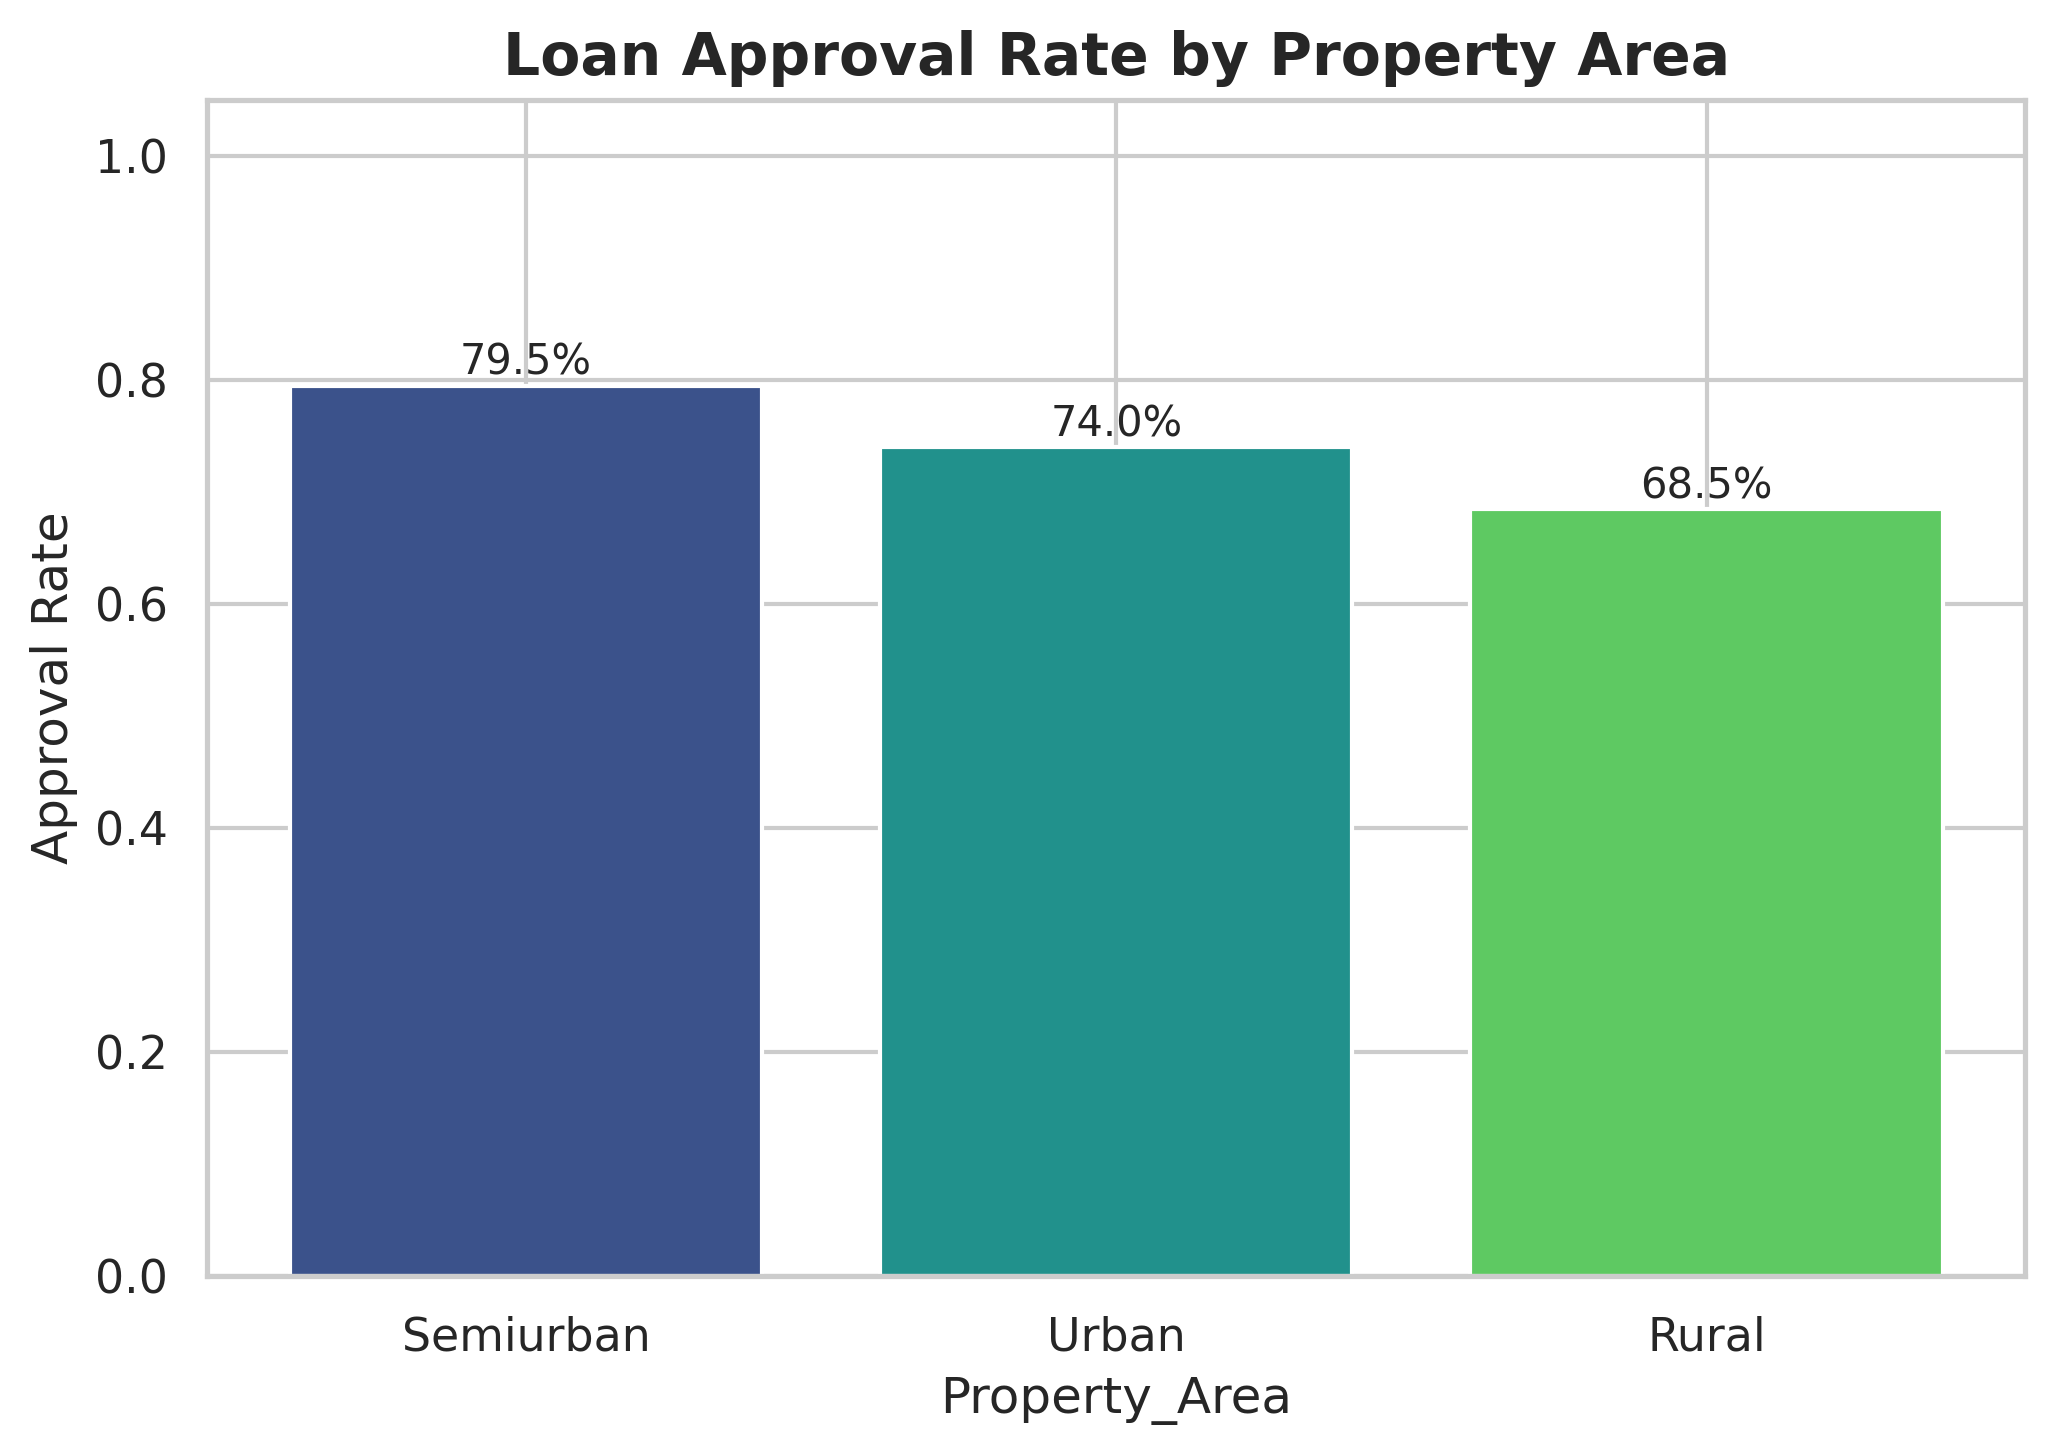

In [3]:
plot_approval_rate_by_category(
    raw_df, 'Property_Area', 'Loan_Status',
    'Loan Approval Rate by Property Area',
    config.IMAGES_DIR / 'approval_property_area.png'
)
display(Image(filename=str(config.IMAGES_DIR / 'approval_property_area.png')))

## Approval Rate by Education

[2026-07-31 19:26:20] INFO - src.visualization - Saved figure: /home/claude/AIML-BonusProject-Loan-Risk-Assessment/Images/approval_education.png


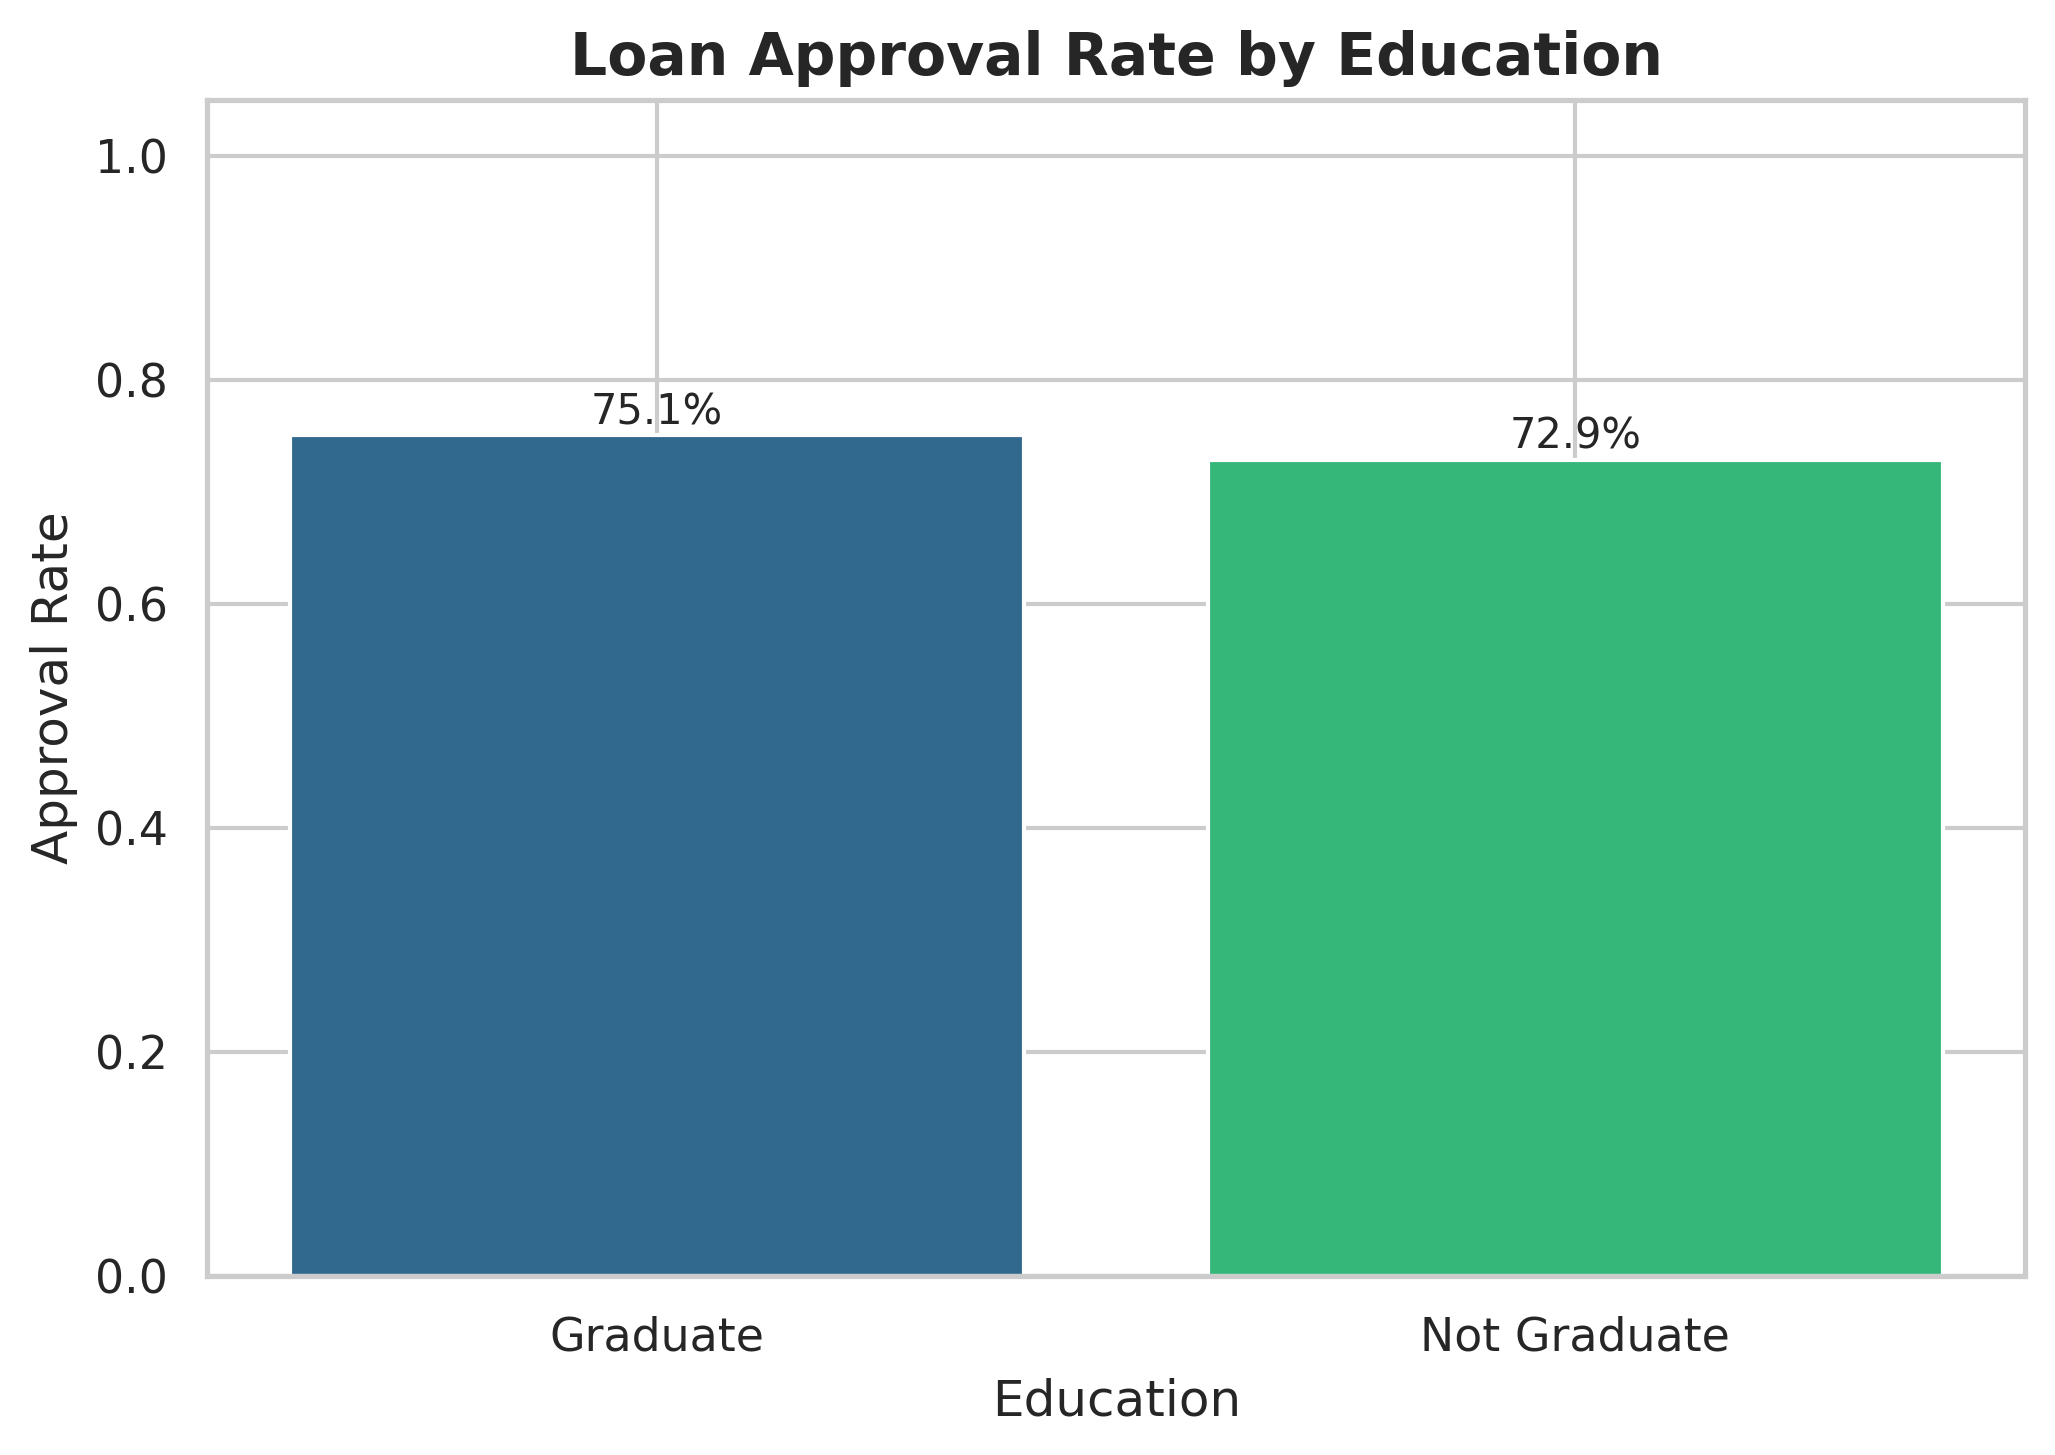

In [4]:
plot_approval_rate_by_category(
    raw_df, 'Education', 'Loan_Status',
    'Loan Approval Rate by Education',
    config.IMAGES_DIR / 'approval_education.png'
)
display(Image(filename=str(config.IMAGES_DIR / 'approval_education.png')))

## Numeric Feature Distributions

[2026-07-31 19:26:20] INFO - src.visualization - Saved figure: /home/claude/AIML-BonusProject-Loan-Risk-Assessment/Images/applicant_income_distribution.png


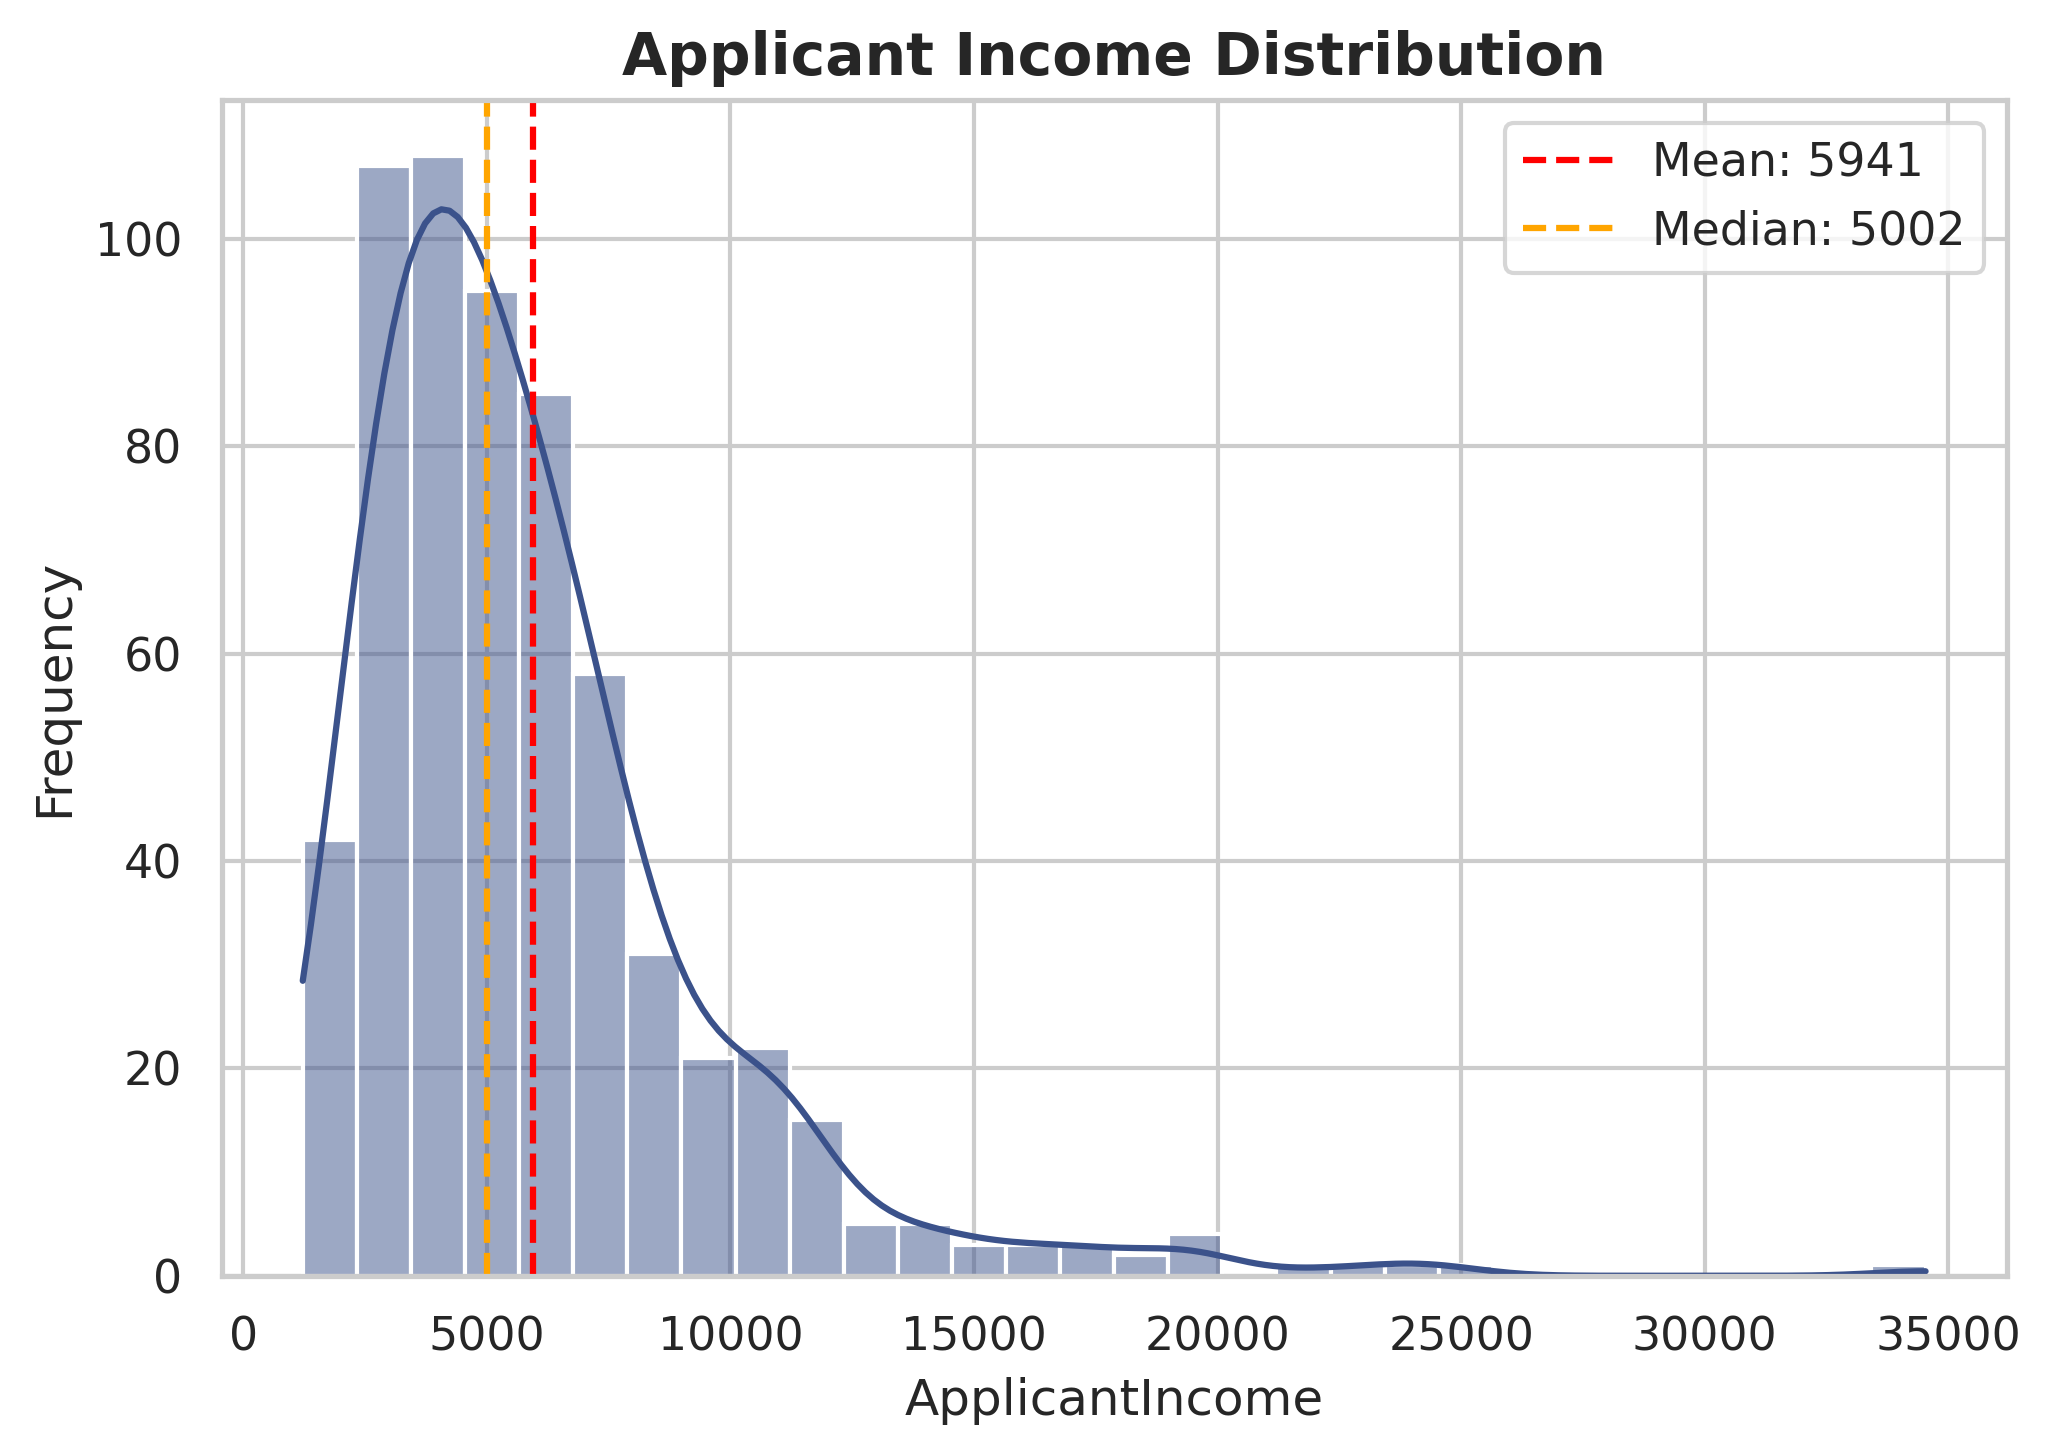

In [5]:
plot_distribution(engineered_df, 'ApplicantIncome', 'Applicant Income Distribution',
                   config.IMAGES_DIR / 'applicant_income_distribution.png')
display(Image(filename=str(config.IMAGES_DIR / 'applicant_income_distribution.png')))

[2026-07-31 19:26:20] INFO - src.visualization - Saved figure: /home/claude/AIML-BonusProject-Loan-Risk-Assessment/Images/coapplicant_income_distribution.png


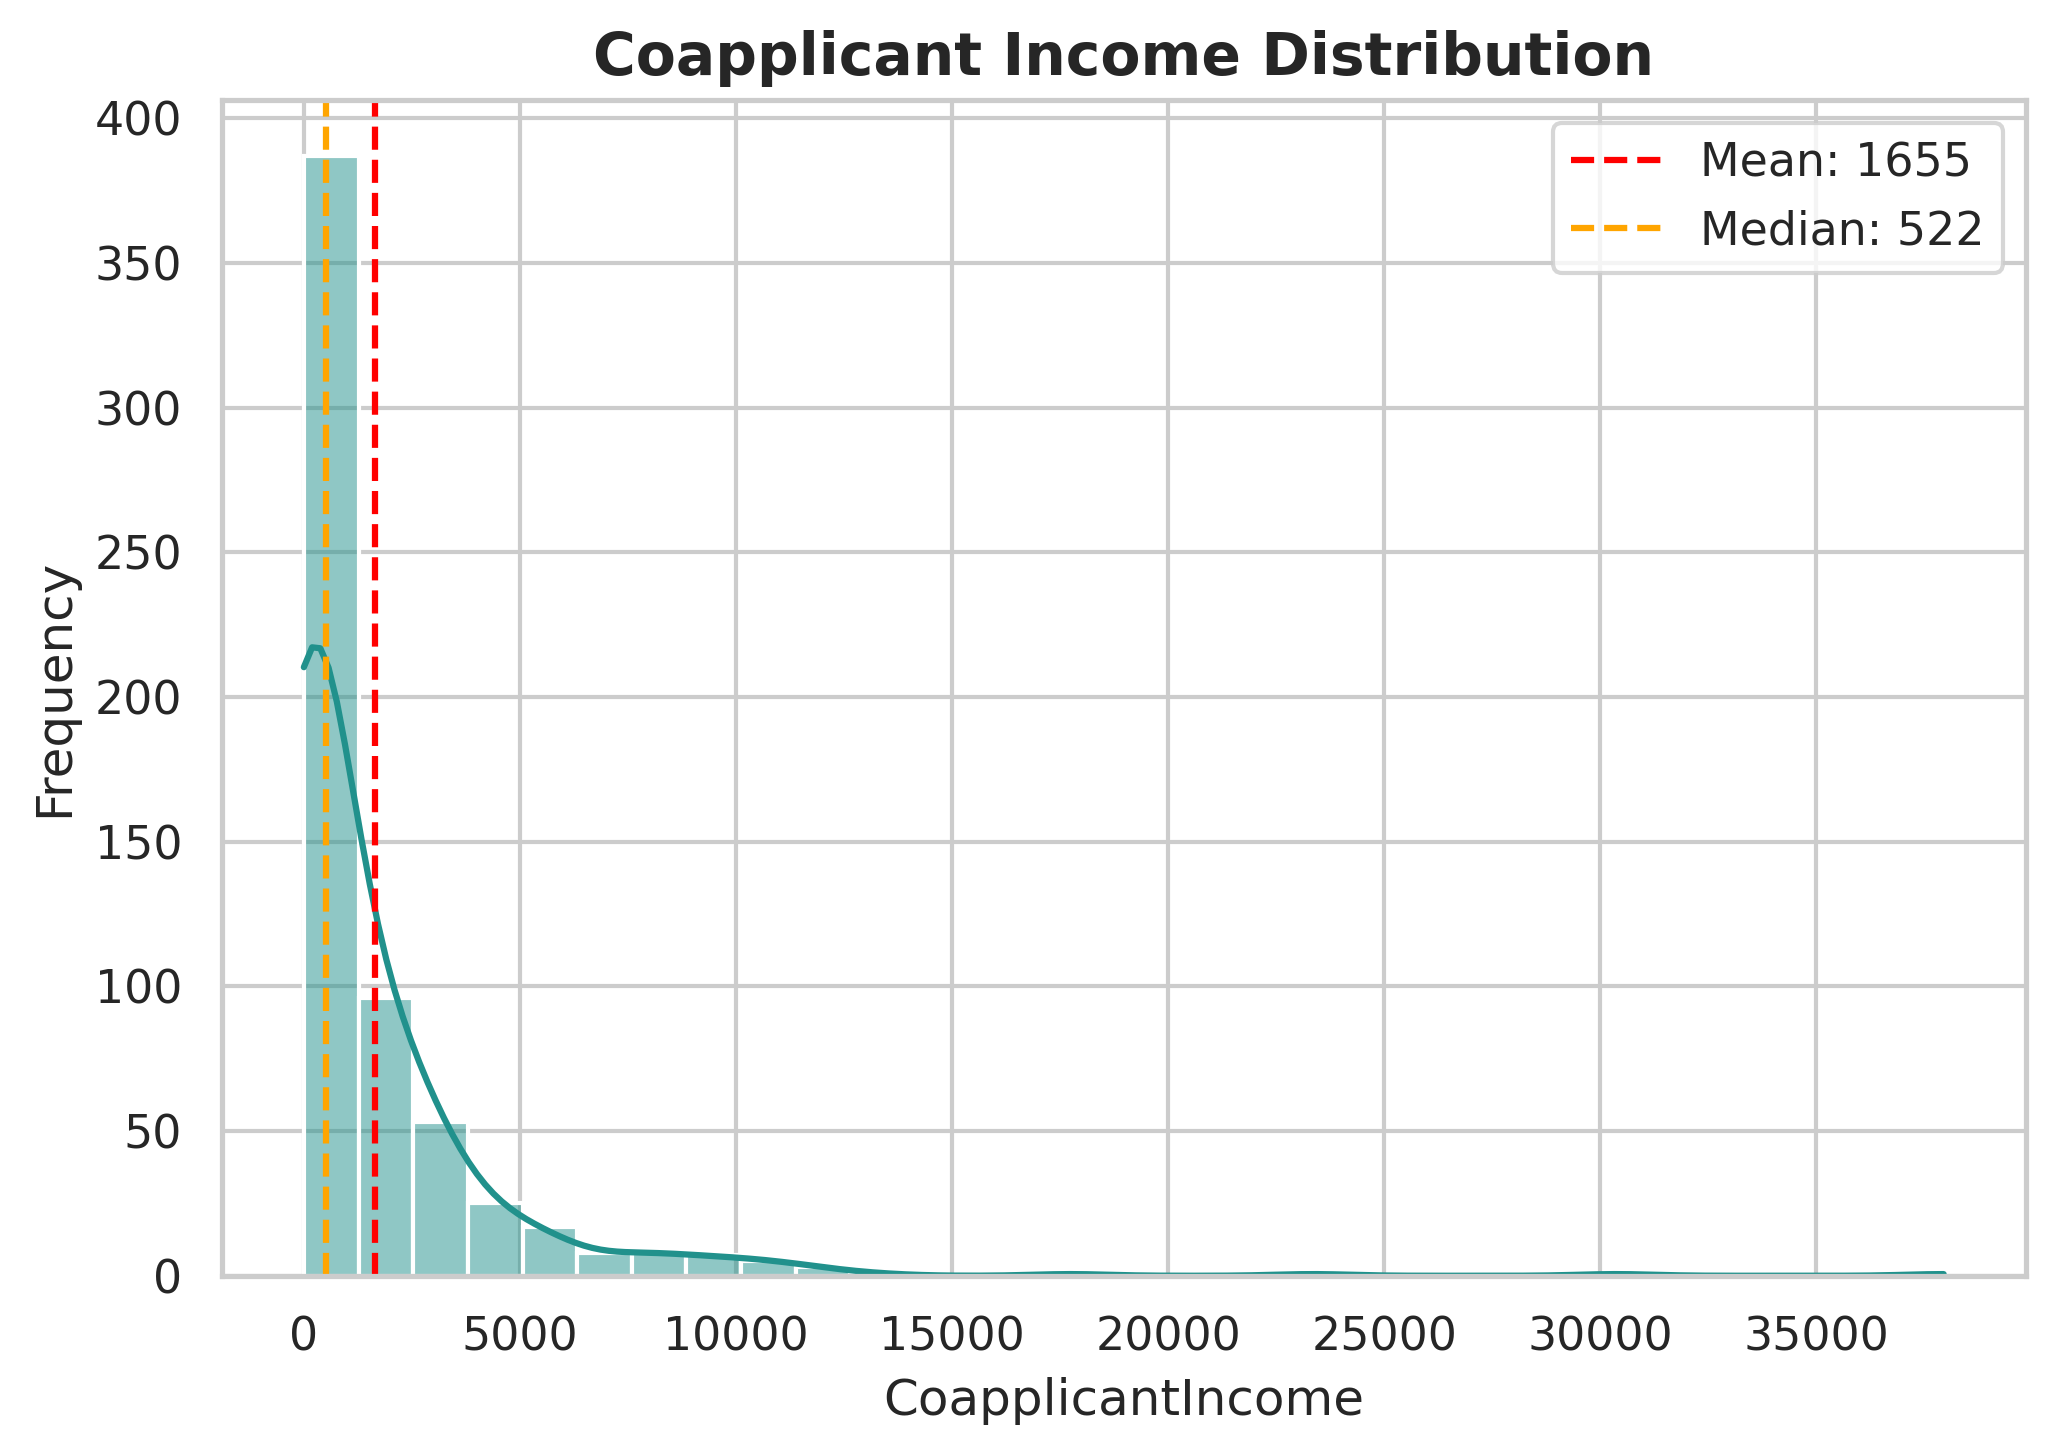

In [6]:
plot_distribution(engineered_df, 'CoapplicantIncome', 'Coapplicant Income Distribution',
                   config.IMAGES_DIR / 'coapplicant_income_distribution.png', color='#21918c')
display(Image(filename=str(config.IMAGES_DIR / 'coapplicant_income_distribution.png')))

[2026-07-31 19:26:21] INFO - src.visualization - Saved figure: /home/claude/AIML-BonusProject-Loan-Risk-Assessment/Images/loan_amount_distribution.png


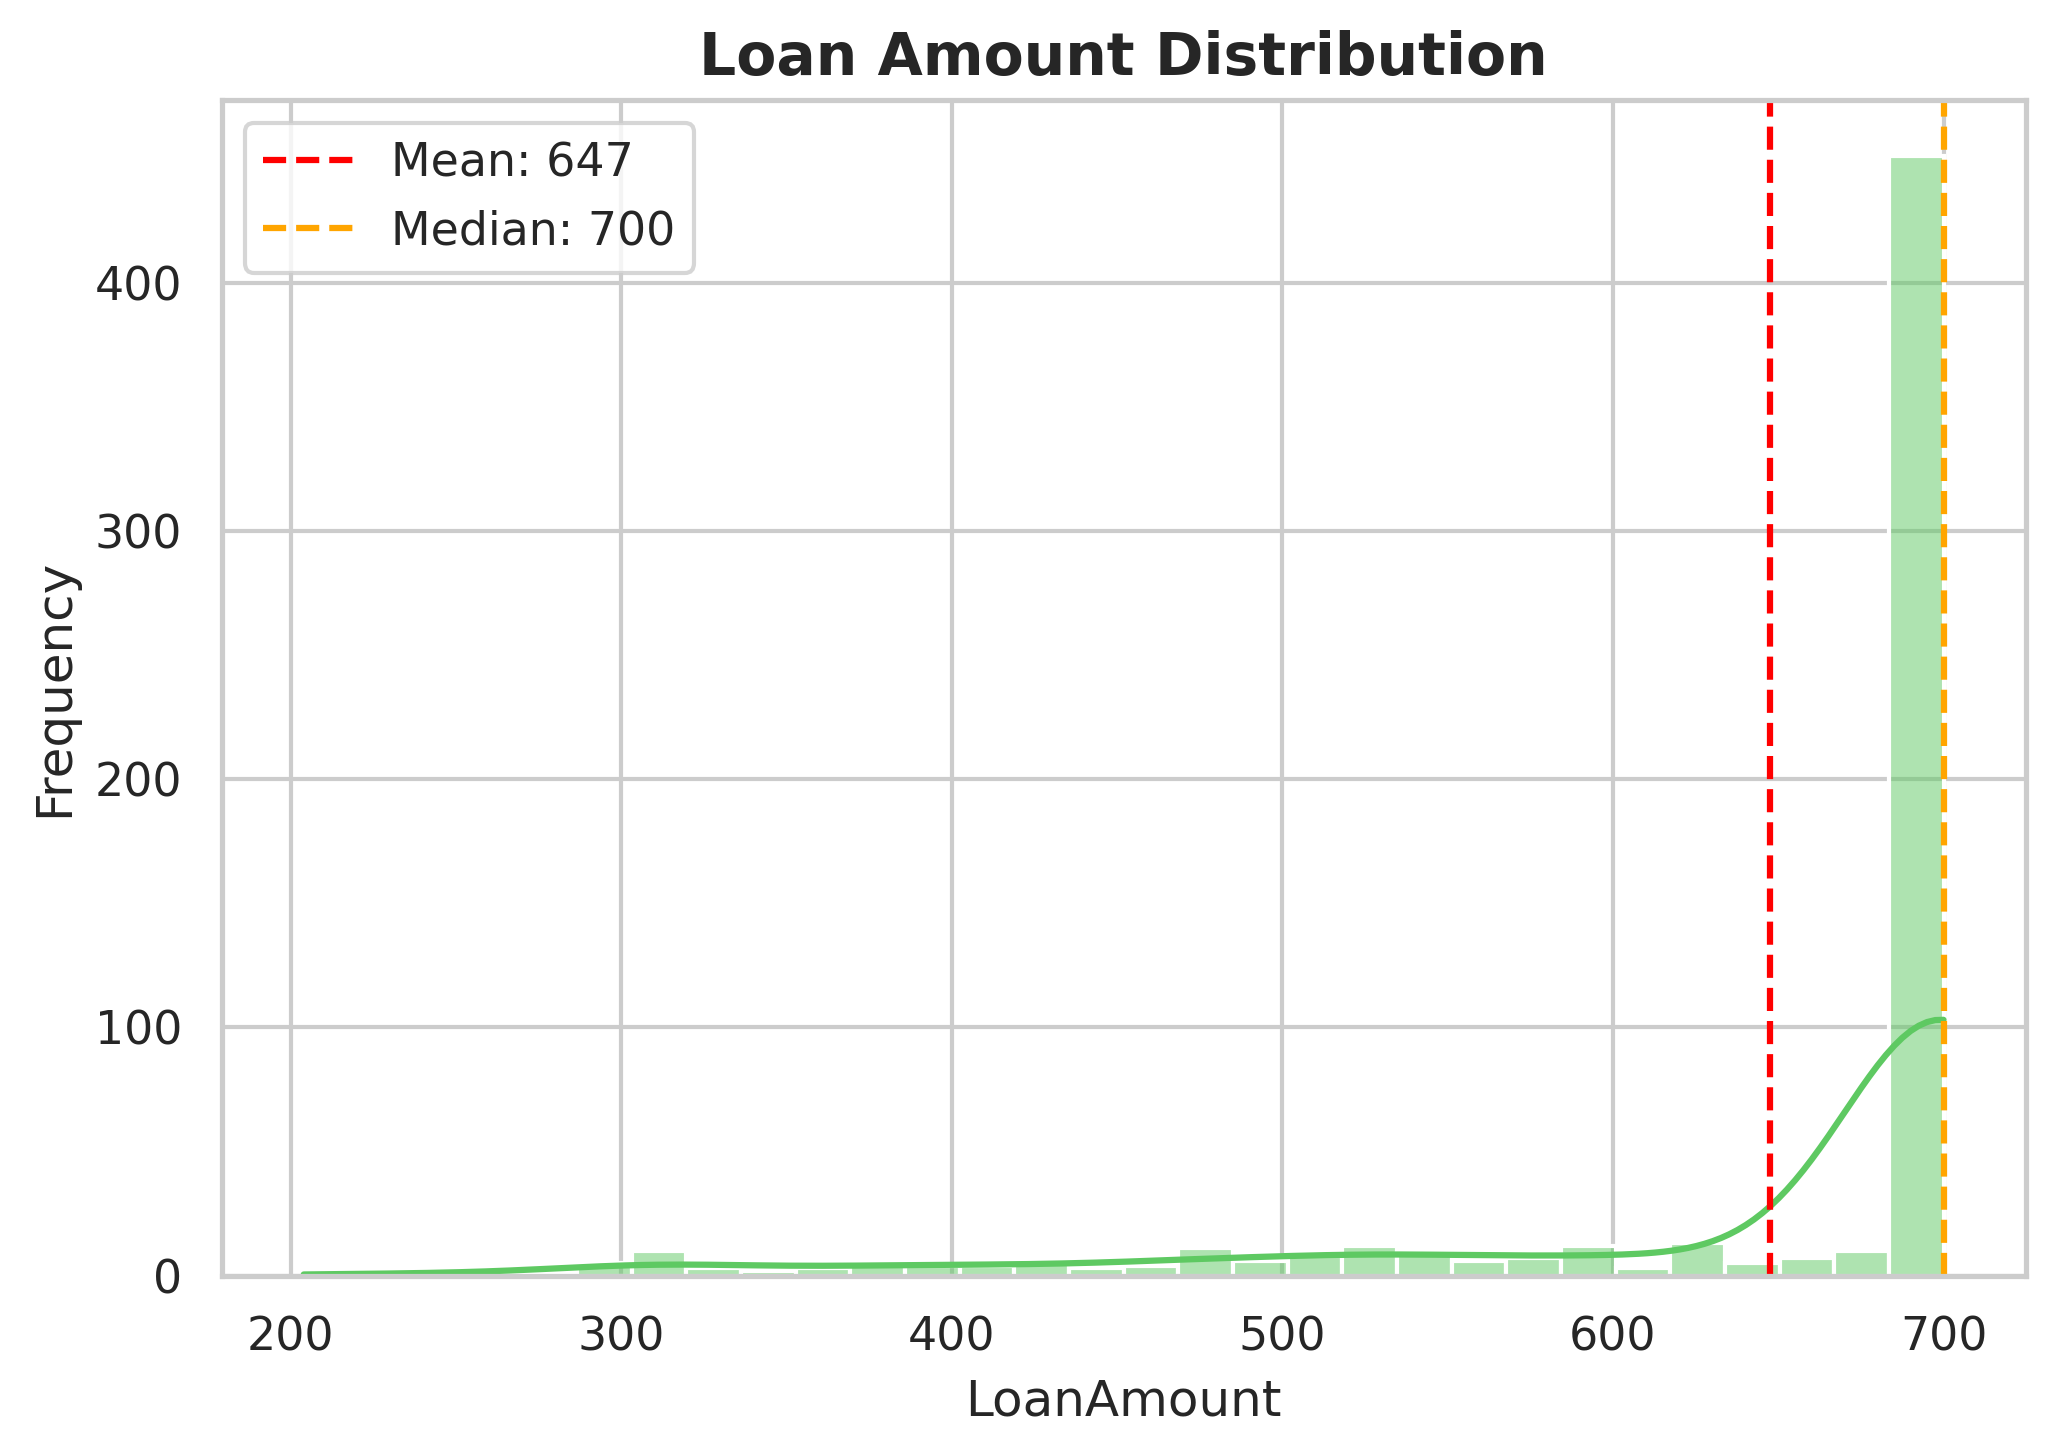

In [7]:
plot_distribution(engineered_df, 'LoanAmount', 'Loan Amount Distribution',
                   config.IMAGES_DIR / 'loan_amount_distribution.png', color='#5ec962')
display(Image(filename=str(config.IMAGES_DIR / 'loan_amount_distribution.png')))

[2026-07-31 19:26:21] INFO - src.visualization - Saved figure: /home/claude/AIML-BonusProject-Loan-Risk-Assessment/Images/total_income_distribution.png


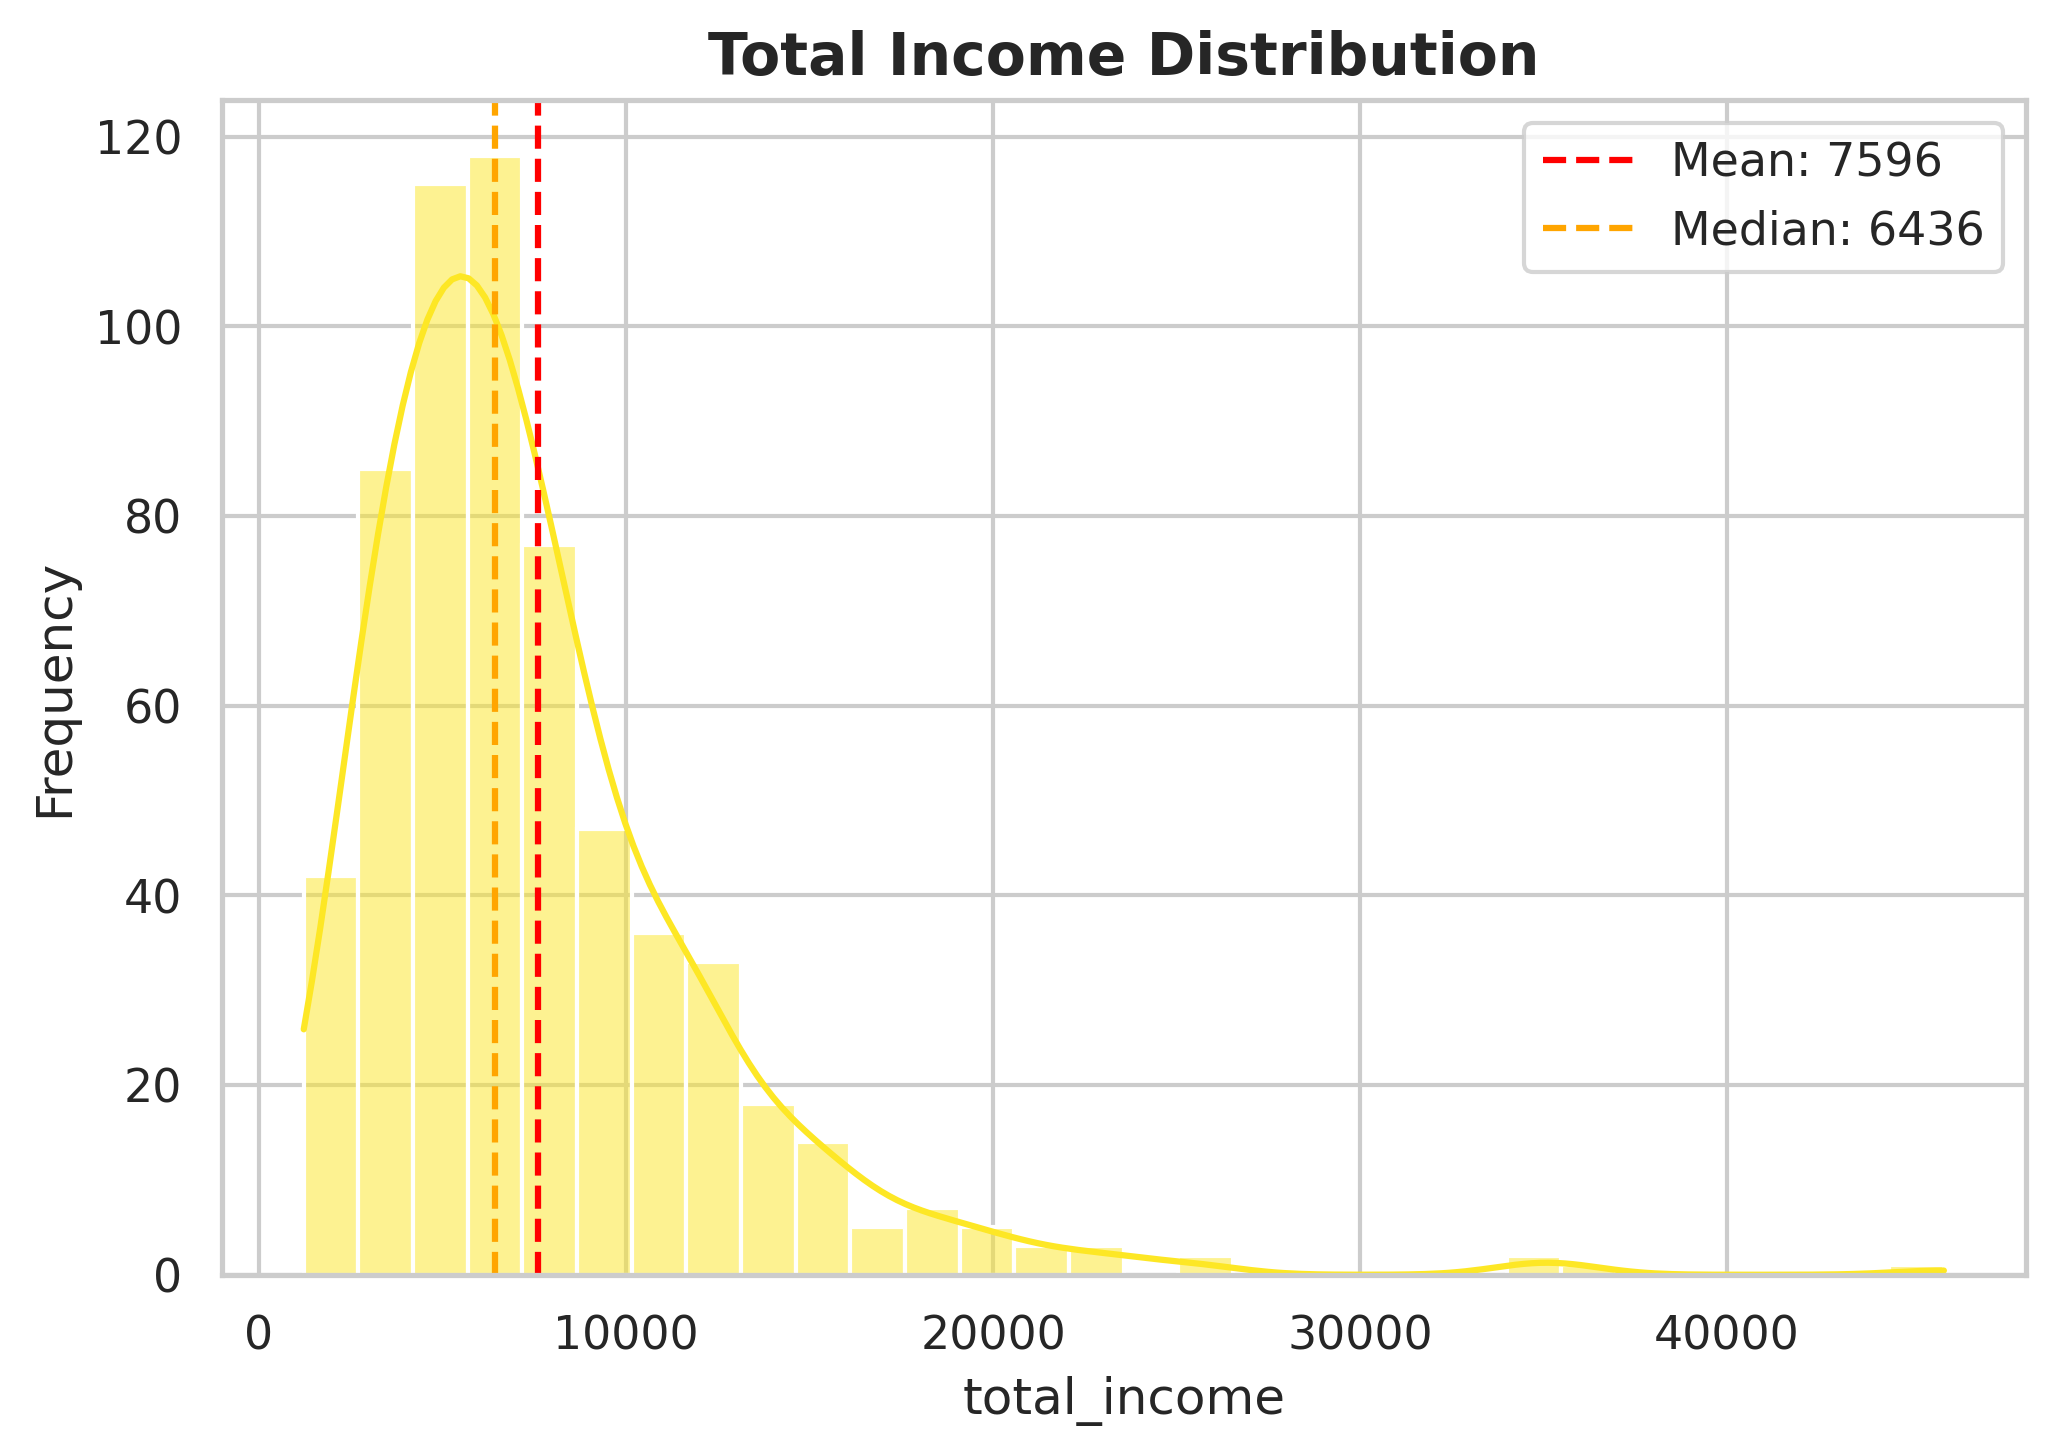

In [8]:
plot_distribution(engineered_df, 'total_income', 'Total Income Distribution',
                   config.IMAGES_DIR / 'total_income_distribution.png', color='#fde725')
display(Image(filename=str(config.IMAGES_DIR / 'total_income_distribution.png')))

[2026-07-31 19:26:21] INFO - src.visualization - Saved figure: /home/claude/AIML-BonusProject-Loan-Risk-Assessment/Images/loan_income_ratio_distribution.png


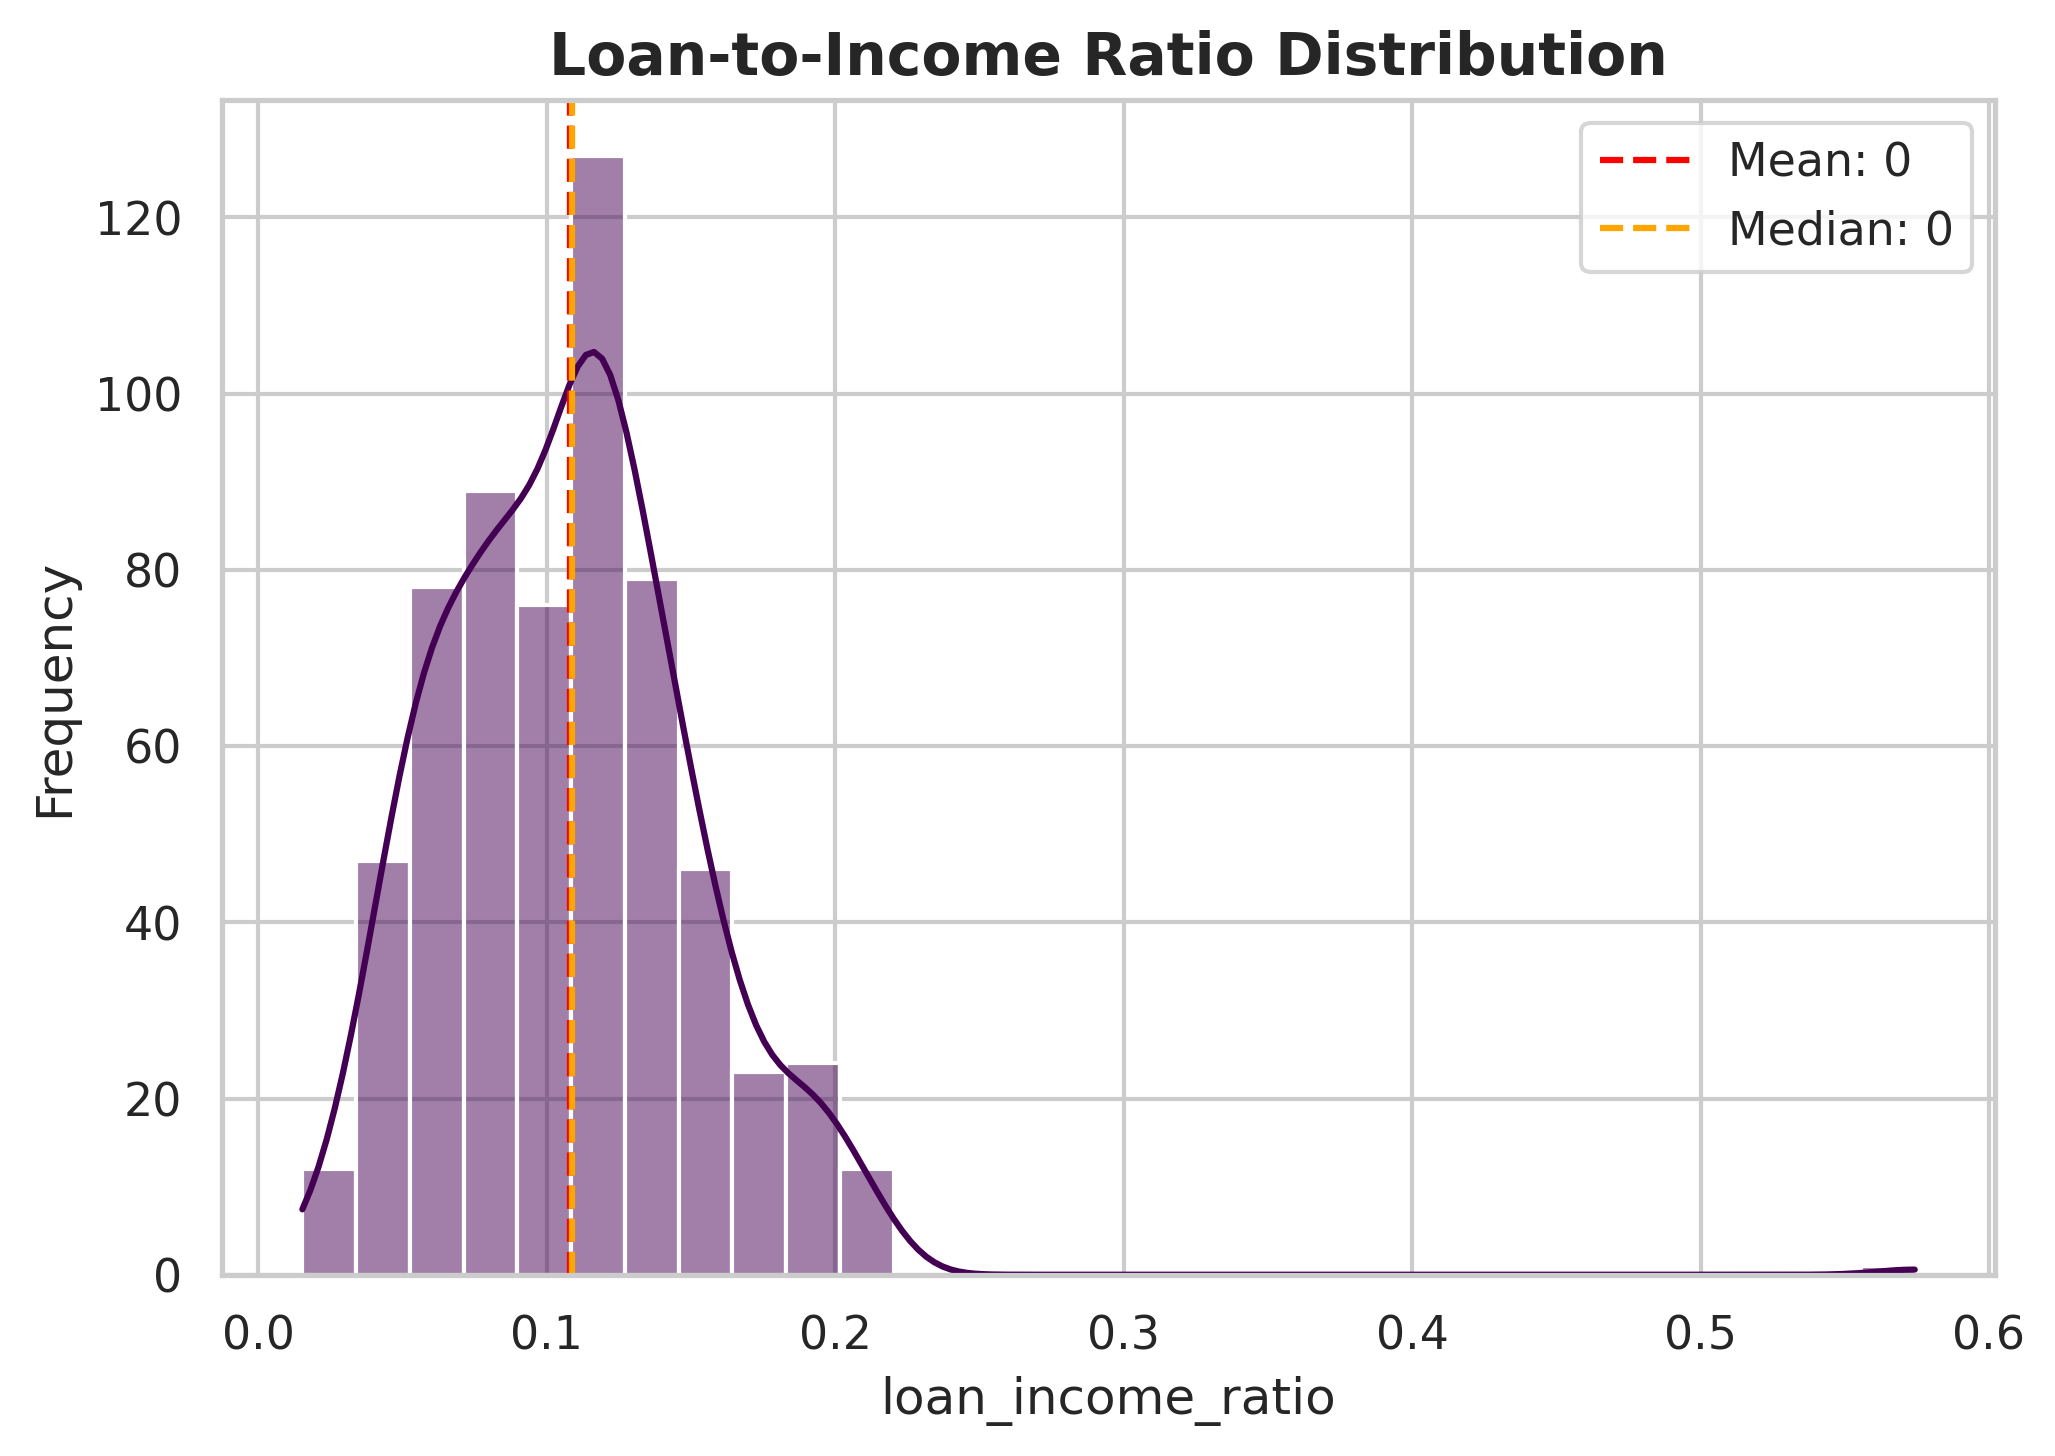

In [9]:
plot_distribution(engineered_df, 'loan_income_ratio', 'Loan-to-Income Ratio Distribution',
                   config.IMAGES_DIR / 'loan_income_ratio_distribution.png', color='#440154')
display(Image(filename=str(config.IMAGES_DIR / 'loan_income_ratio_distribution.png')))

## Correlation Heatmap

[2026-07-31 19:26:22] INFO - src.visualization - Saved figure: /home/claude/AIML-BonusProject-Loan-Risk-Assessment/Images/correlation_heatmap.png


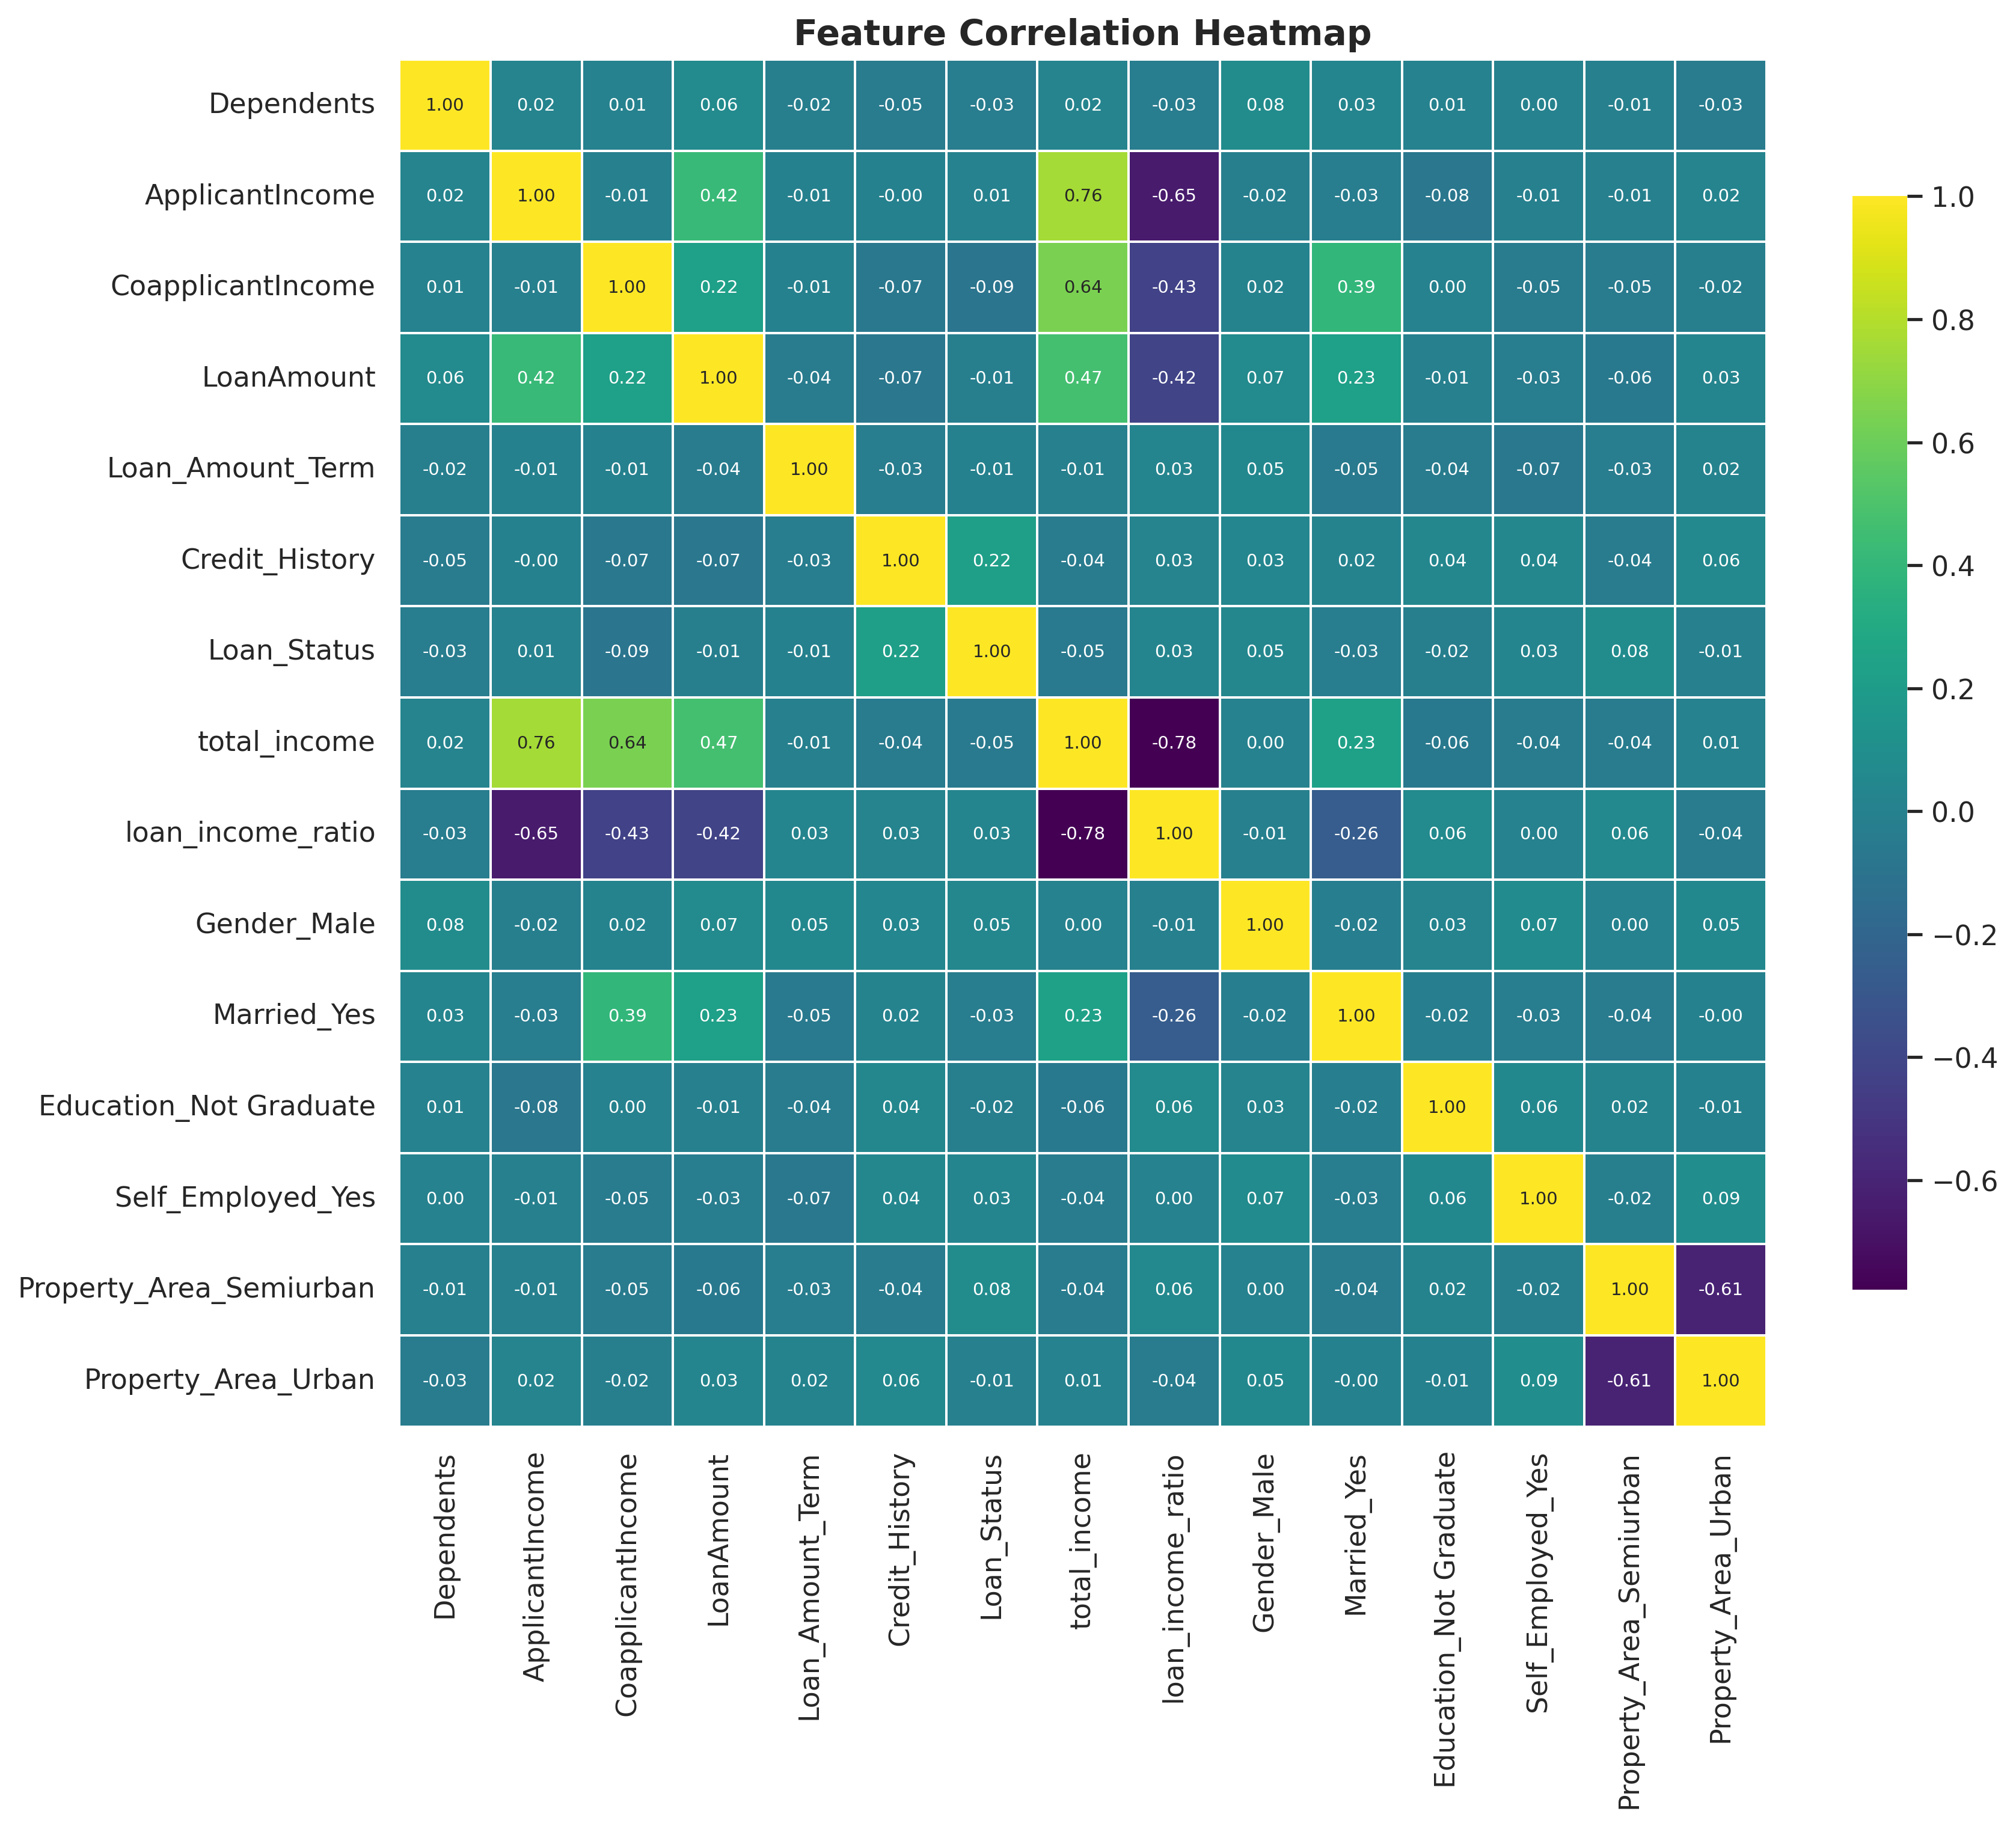

In [10]:
plot_correlation_heatmap(engineered_df, config.IMAGES_DIR / 'correlation_heatmap.png')
display(Image(filename=str(config.IMAGES_DIR / 'correlation_heatmap.png')))

## Conclusion

Key EDA findings:
- **Credit History** shows the strongest relationship with loan approval — applicants with a confirmed good credit history are approved at a substantially higher rate.
- **Semiurban properties** tend to have a somewhat higher approval rate than urban or rural properties.
- **Graduates** show marginally higher approval rates than non-graduates.
- Income and loan amount distributions are **right-skewed**, consistent with typical real-world income data, motivating the engineered `loan_income_ratio` feature as a more normalized risk signal.
- The correlation heatmap confirms `Credit_History` and `loan_income_ratio` are among the features most associated with the target.